<a href="https://colab.research.google.com/github/XM149/DSAN-6500-Final_Project/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA and initial baseline/representation

In [1]:
%pip install pycocotools ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.5 MB/s eta 0:00:00


## Dataset loading


In [3]:
!mkdir -p /content/data/coco
%cd /content/data/coco

/content/data/coco


In [ ]:
!wget http://images.cocodataset.org/zips/val2017.zip
!unzip val2017.zip

In [5]:
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip annotations_trainval2017.zip

--2026-03-08 17:00:50--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.90.44, 16.182.105.49, 52.217.122.169, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.90.44|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_trainva 100%[===================>] 241.19M  62.1MB/s    in 4.3s    

2026-03-08 17:00:54 (56.0 MB/s) - ‘annotations_trainval2017.zip’ saved [252907541/252907541]

Archive:  annotations_trainval2017.zip
  inflating: annotations/instances_train2017.json  
  inflating: annotations/instances_val2017.json  
  inflating: annotations/captions_train2017.json  
  inflating: annotations/captions_val2017.json  
  inflating: annotations/person_keypoints_train2017.json  
  inflating: annotations/person_keypoints_val2017.json  


In [6]:
!ls

annotations  annotations_trainval2017.zip  val2017  val2017.zip


In [7]:
# Environment verification
import sys
import torch
import torchvision
import ultralytics

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Ultralytics:", ultralytics.__version__)
print("CUDA available:", torch.cuda.is_available())

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Ultralytics: 8.4.21
CUDA available: True


In [8]:
import torchvision.datasets as dset
import torchvision.transforms as transforms
from torch.utils.data import Subset

COCO_IMG_DIR = "/content/data/coco/val2017"
COCO_ANN_FILE = "/content/data/coco/annotations/instances_val2017.json"

full_dataset = dset.CocoDetection(
    root=COCO_IMG_DIR,
    annFile=COCO_ANN_FILE,
    transform=transforms.ToTensor()
)

print("Full dataset size:", len(full_dataset))

# COCO food category IDs
TARGET_CAT_IDS = {52, 53, 54, 55, 56, 57, 58, 59, 60, 61}

# Remap to YOLO-style class IDs (0-indexed)
COCO_TO_NEW = {
    52: 0,  # banana
    53: 1,  # apple
    54: 2,  # sandwich
    55: 3,  # orange
    56: 4,  # broccoli
    57: 5,  # carrot
    58: 6,  # hot dog
    59: 7,  # pizza
    60: 8,  # donut
    61: 9   # cake
}

NEW_TO_NAME = {
    0: "banana",
    1: "apple",
    2: "sandwich",
    3: "orange",
    4: "broccoli",
    5: "carrot",
    6: "hot dog",
    7: "pizza",
    8: "donut",
    9: "cake"
}

NUM_CLASSES = 10

# Filter images containing at least one food category
keep_indices = []

for idx in range(len(full_dataset)):
    img_id = full_dataset.ids[idx]
    ann_ids = full_dataset.coco.getAnnIds(
        imgIds=img_id,
        catIds=list(TARGET_CAT_IDS)
    )

    if len(ann_ids) > 0:
        keep_indices.append(idx)

dataset = Subset(full_dataset, keep_indices)

print(f"Filtered dataset size: {len(dataset)} (images with food categories)")

loading annotations into memory...
Done (t=1.76s)
creating index...
index created!
Full dataset size: 5000
Filtered dataset size: 708 (images with food categories)


## Detection visualization and Dataset statistics

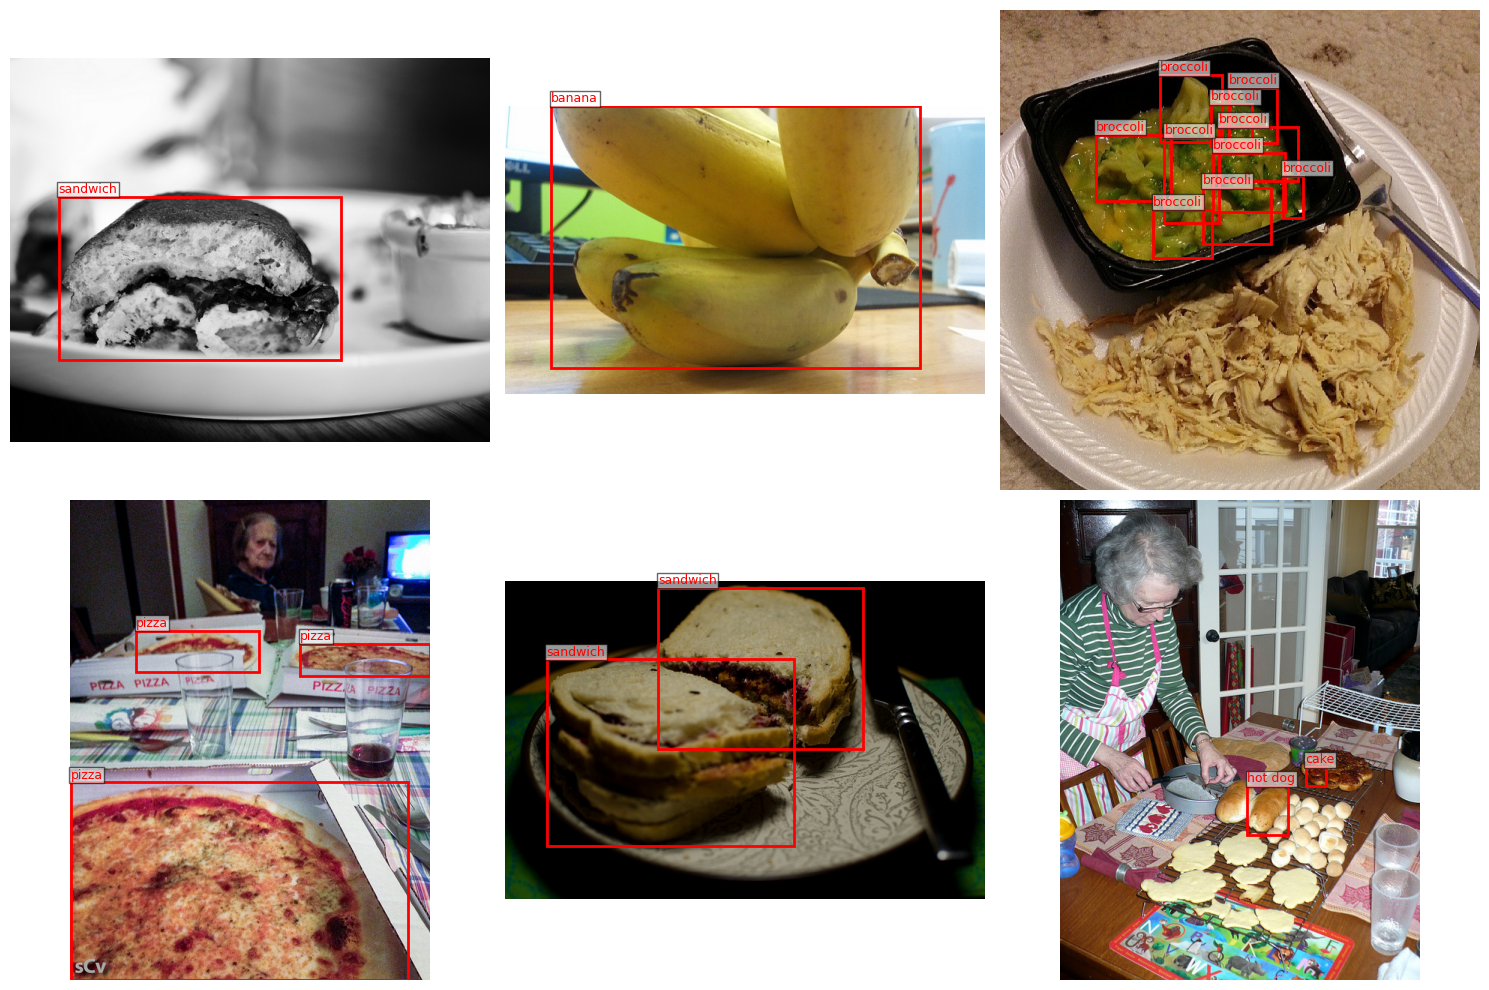

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# visualize a few images with ground-truth boxes (food categories)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sample_indices = [0, 5, 10, 15, 20, 25]

axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):

    img, target = dataset[idx]

    ax.imshow(img.permute(1, 2, 0))

    for ann in target:
        if ann["category_id"] not in TARGET_CAT_IDS:
            continue

        x, y, w, h = ann["bbox"]
        cat_name = NEW_TO_NAME[COCO_TO_NEW[ann["category_id"]]]

        rect = patches.Rectangle((x, y), w, h,
                                 fill=False,
                                 edgecolor="red",
                                 linewidth=2)

        ax.add_patch(rect)

        ax.text(x, y-5, cat_name,
                color="red",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.6, pad=1))

    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
from collections import Counter

bbox_counter = Counter()

for idx in keep_indices:
    _, anns = full_dataset[idx]

    for ann in anns:
        cat_id = ann["category_id"]

        if cat_id in TARGET_CAT_IDS:
            class_id = COCO_TO_NEW[cat_id]
            bbox_counter[class_id] += 1

print("Bounding box count per class:")

for class_id, count in bbox_counter.items():
    print(NEW_TO_NAME[class_id], ":", count)

Bounding box count per class:
sandwich : 177
apple : 239
cake : 316
banana : 379
donut : 338
broccoli : 316
carrot : 371
orange : 287
pizza : 285
hot dog : 127


In [12]:
image_counter = Counter()

for idx in keep_indices:

    _, anns = full_dataset[idx]

    categories_in_image = set()

    for ann in anns:
        if ann["category_id"] in TARGET_CAT_IDS:
            categories_in_image.add(COCO_TO_NEW[ann["category_id"]])

    for c in categories_in_image:
        image_counter[c] += 1

print("Image count per class:")

for class_id, count in image_counter.items():
    print(NEW_TO_NAME[class_id], ":", count)

Image count per class:
sandwich : 98
apple : 76
cake : 124
banana : 103
donut : 62
broccoli : 71
carrot : 81
orange : 85
pizza : 153
hot dog : 51


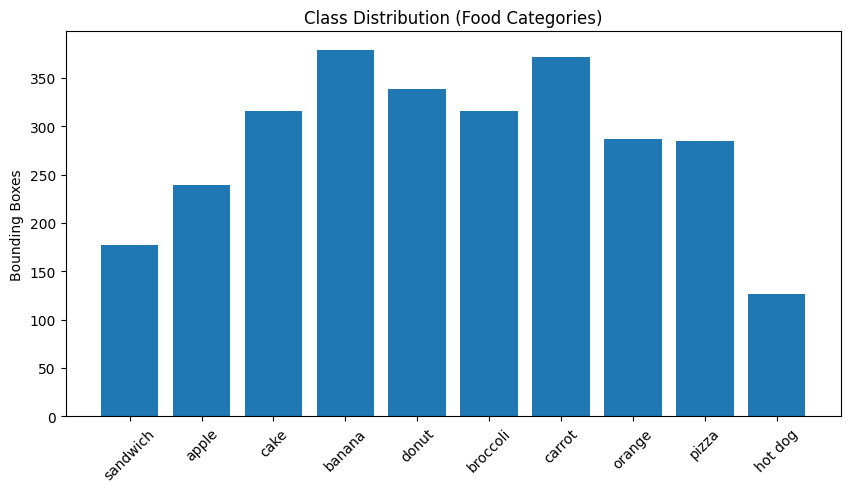

In [13]:
import matplotlib.pyplot as plt

classes = [NEW_TO_NAME[i] for i in bbox_counter.keys()]
counts = [bbox_counter[i] for i in bbox_counter.keys()]

plt.figure(figsize=(10,5))
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.ylabel("Bounding Boxes")
plt.title("Class Distribution (Food Categories)")
plt.show()

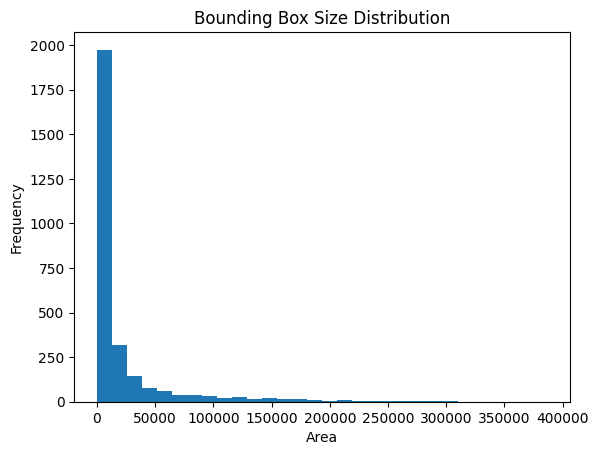

In [14]:
box_sizes = []

for idx in keep_indices:
    _, anns = full_dataset[idx]

    for ann in anns:
        if ann["category_id"] in TARGET_CAT_IDS:
            x,y,w,h = ann["bbox"]
            box_sizes.append(w*h)

plt.hist(box_sizes, bins=30)
plt.title("Bounding Box Size Distribution")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.show()

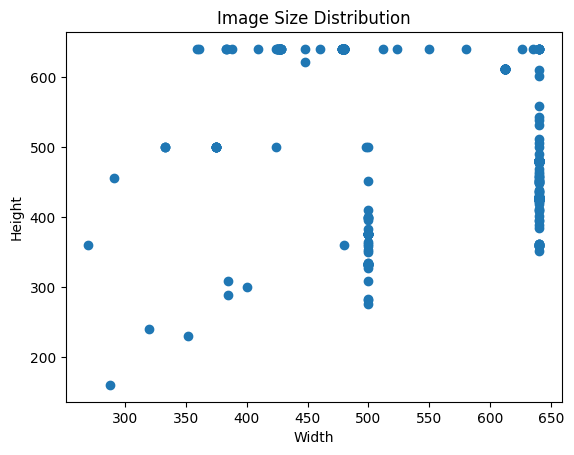

In [16]:
widths = []
heights = []

for idx in range(min(500, len(dataset))):

    img, _ = dataset[idx]

    h, w = img.shape[1], img.shape[2]

    widths.append(w)
    heights.append(h)

plt.scatter(widths, heights)
plt.title("Image Size Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

## Baseline / Representation

In [18]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn

# load pretrained model
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 180MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [19]:
img, target = dataset[0]

with torch.no_grad():
    prediction = model([img])

In [20]:
prediction[0].keys()

# boxes
# labels
# scores

dict_keys(['boxes', 'labels', 'scores'])

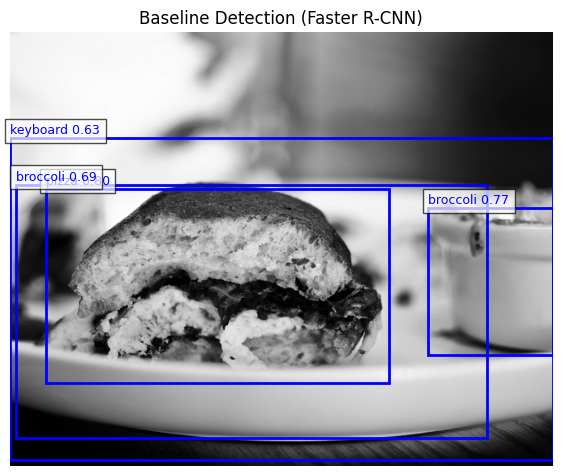

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# COCO class names (80 classes)
COCO_CLASSES = [
"__background__","person","bicycle","car","motorcycle","airplane","bus","train",
"truck","boat","traffic light","fire hydrant","stop sign","parking meter","bench",
"bird","cat","dog","horse","sheep","cow","elephant","bear","zebra","giraffe",
"backpack","umbrella","handbag","tie","suitcase","frisbee","skis","snowboard",
"sports ball","kite","baseball bat","baseball glove","skateboard","surfboard",
"tennis racket","bottle","wine glass","cup","fork","knife","spoon","bowl",
"banana","apple","sandwich","orange","broccoli","carrot","hot dog","pizza",
"donut","cake","chair","couch","potted plant","bed","dining table","toilet",
"tv","laptop","mouse","remote","keyboard","cell phone","microwave","oven",
"toaster","sink","refrigerator","book","clock","vase","scissors","teddy bear",
"hair drier","toothbrush"
]

img, _ = dataset[0]

with torch.no_grad():
    prediction = model([img])[0]

boxes = prediction["boxes"]
labels = prediction["labels"]
scores = prediction["scores"]

fig, ax = plt.subplots(1, figsize=(7,7))
ax.imshow(img.permute(1,2,0))

for box, label, score in zip(boxes, labels, scores):

    if score < 0.6:
        continue

    x1, y1, x2, y2 = box
    w = x2 - x1
    h = y2 - y1

    rect = patches.Rectangle(
        (x1, y1),
        w,
        h,
        linewidth=2,
        edgecolor="blue",
        facecolor="none"
    )

    ax.add_patch(rect)

    class_name = COCO_CLASSES[label]

    ax.text(
        x1,
        y1 - 5,
        f"{class_name} {score:.2f}",
        color="blue",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.7)
    )

plt.title("Baseline Detection (Faster R-CNN)")
plt.axis("off")
plt.show()